In [1]:
import os

# Optional notebook-only setup:
# Uncomment and set the key only for this running kernel session.
# os.environ["OPENAI_API_KEY"] = "your_openai_api_key_here"

print("OPENAI_API_KEY loaded:", bool(os.getenv("OPENAI_API_KEY")))

OPENAI_API_KEY loaded: True


In [2]:
import os
import base64
import json
import pandas as pd
from tqdm import tqdm
from openai import OpenAI
from PIL import Image
import pillow_heif

pillow_heif.register_heif_opener()

# Read API key from env var and fail fast with a helpful message.
# Optional fallback for notebook-only usage: set OPENAI_API_KEY_INLINE to your key.
OPENAI_API_KEY_INLINE = ""

api_key = os.getenv("OPENAI_API_KEY") or OPENAI_API_KEY_INLINE
if not api_key:
    raise ValueError(
        "OPENAI_API_KEY is not set. Set it in your environment (or OPENAI_API_KEY_INLINE in this cell)."
    )

client = OpenAI(api_key=api_key)

IMAGE_FOLDER = "images"  # folder containing IMG_XXXX.HEIC
OUTPUT_CSV = "questionnaire_results.csv"

In [3]:
def encode_image(path):
    """
    Convert HEIC/JPG/PNG to base64 JPEG for the API
    """
    img = Image.open(path)
    img = img.convert("RGB")

    import io
    buffer = io.BytesIO()
    img.save(buffer, format="JPEG")
    
    return base64.b64encode(buffer.getvalue()).decode()


def group_images(folder):
    """
    Sort files and group every two images as one respondent
    Handles missing numbers (IMG_2712, IMG_2714 still paired)
    """
    files = sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".heic", ".jpg", ".jpeg", ".png"))
    ])

    groups = []
    
    for i in range(0, len(files), 2):
        pair = files[i:i+2]
        if len(pair) == 2:
            groups.append(pair)

    return groups

In [4]:
PROMPT = """
You are extracting structured survey data.

The images show a filled questionnaire.

Return JSON with these fields:

age_group
gender

Q3
Q4
Q5
Q6
Q7
Q8
Q9
Q10
Q11
Q12
Q13
Q14
Q15
Q16
Q17
Q18
Q19
Q20
Q21

comment
application_area

Rules:
- Likert answers must be integers 1–5
- If blank return null
- Return ONLY valid JSON
"""

In [5]:
def _parse_json_response(text):
    """
    Parse model output as JSON, tolerating fenced code blocks.
    """
    cleaned = text.strip()

    if cleaned.startswith("```"):
        lines = cleaned.splitlines()
        if lines and lines[0].startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].strip() == "```":
            lines = lines[:-1]
        cleaned = "\n".join(lines).strip()

    return json.loads(cleaned)


def extract_response(image_paths):
    encoded_images = [encode_image(p) for p in image_paths]

    response = client.responses.create(
        model="gpt-4.1",
        input=[{
            "role": "user",
            "content": [
                {"type": "input_text", "text": PROMPT},
                *[
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{img}"
                    }
                    for img in encoded_images
                ]
            ]
        }]
    )

    return _parse_json_response(response.output_text)

In [6]:
groups = group_images(IMAGE_FOLDER)

print("Found respondents:", len(groups))

results = []

for pair in tqdm(groups):

    paths = [os.path.join(IMAGE_FOLDER, p) for p in pair]

    try:
        data = extract_response(paths)
        data["image_files"] = ",".join(pair)
        results.append(data)

    except Exception as e:
        print("Error processing:", pair, e)

Found respondents: 23


100%|██████████| 23/23 [02:05<00:00,  5.47s/it]


In [7]:
df = pd.DataFrame(results)

df.to_csv(OUTPUT_CSV, index=False)

print("Saved to", OUTPUT_CSV)

Saved to questionnaire_results.csv


In [8]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, mannwhitneyu

# =========================
# Load data
# =========================
df = pd.read_csv("questionnaire_results.csv")

# =========================
# Define questionnaire structure
# =========================
likert_items = [f"Q{i}" for i in range(3, 22)]

constructs = {
    "Perceived Usefulness": ["Q3", "Q4"],
    "Clarity": ["Q5", "Q6", "Q7", "Q8", "Q9"],
    "Social Expressiveness & Appropriateness": ["Q10", "Q11", "Q12", "Q13", "Q14", "Q15", "Q16"],
    "Trust, Safety & Comfort": ["Q17", "Q18", "Q19", "Q20", "Q21"],
}

# Negatively worded items from the questionnaire
reverse_scored = ["Q19", "Q20"]   # 1<->5, 2<->4, 3 stays 3

# Make a working copy
data = df.copy()

# Ensure Likert items are numeric
for col in likert_items:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Reverse-code negative items for construct/reliability analysis
for col in reverse_scored:
    data[col + "_R"] = data[col].apply(lambda x: 6 - x if pd.notna(x) else np.nan)

constructs_scored = {
    "Perceived Usefulness": ["Q3", "Q4"],
    "Clarity": ["Q5", "Q6", "Q7", "Q8", "Q9"],
    "Social Expressiveness & Appropriateness": ["Q10", "Q11", "Q12", "Q13", "Q14", "Q15", "Q16"],
    "Trust, Safety & Comfort": ["Q17", "Q18", "Q19_R", "Q20_R", "Q21"],
}

# =========================
# Helpers
# =========================
def iqr(series):
    s = pd.Series(series).dropna()
    if len(s) == 0:
        return np.nan
    return s.quantile(0.75) - s.quantile(0.25)

def cronbach_alpha(df_items):
    """
    Cronbach's alpha for a dataframe of items (rows=participants, cols=items).
    Drops rows with any missing value within the construct.
    """
    x = df_items.dropna().copy()
    if x.shape[0] < 2 or x.shape[1] < 2:
        return np.nan

    item_vars = x.var(axis=0, ddof=1)
    total_scores = x.sum(axis=1)
    total_var = total_scores.var(ddof=1)

    if total_var == 0:
        return np.nan

    n_items = x.shape[1]
    alpha = (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var)
    return alpha

def safe_shapiro(series):
    s = pd.Series(series).dropna()
    # Shapiro requires at least 3 observations and non-zero variance
    if len(s) < 3 or s.nunique() < 2:
        return pd.Series({"W": np.nan, "p": np.nan, "n": len(s)})
    stat, p = shapiro(s)
    return pd.Series({"W": stat, "p": p, "n": len(s)})

def clean_gender(x):
    """
    Collapse messy OCR gender values into:
    - Man
    - Woman
    - Other/Multiple
    - Missing
    """
    if pd.isna(x):
        return "Missing"

    s = str(x).strip().lower()

    has_man = "man" in s
    has_woman = "woman" in s
    has_nonbinary = "non-binary" in s or "nonbinary" in s or "non conforming" in s or "non-conforming" in s
    has_other = "other" in s or "prefer not" in s

    # Handle multi-select / mixed strings like "['Woman', 'Man']"
    if (has_man and has_woman) or has_nonbinary or has_other:
        return "Other/Multiple"
    elif has_woman:
        return "Woman"
    elif has_man:
        return "Man"
    else:
        return "Other/Multiple"

# =========================
# 1) Item-level descriptive stats
# =========================
item_desc = pd.DataFrame({
    "n": data[likert_items].count(),
    "median": data[likert_items].median(),
    "IQR": data[likert_items].apply(iqr),
    "mean": data[likert_items].mean(),
    "sd": data[likert_items].std(ddof=1),
    "min": data[likert_items].min(),
    "max": data[likert_items].max(),
}).round(3)

print("\n=== ITEM-LEVEL DESCRIPTIVE STATS ===")
display(item_desc)

# =========================
# 2) Shapiro-Wilk normality per item
# =========================
shapiro_results = data[likert_items].apply(safe_shapiro).T.round(4)

print("\n=== SHAPIRO-WILK NORMALITY TESTS (per item) ===")
display(shapiro_results)

# =========================
# 3) Construct scores (participant-level median across items)
#    Median is better for Likert/non-parametric reporting
# =========================
for construct_name, items in constructs_scored.items():
    data[construct_name + "_score"] = data[items].median(axis=1, skipna=True)

construct_score_cols = [c + "_score" for c in constructs_scored.keys()]

construct_desc = pd.DataFrame({
    "n": data[construct_score_cols].count(),
    "median": data[construct_score_cols].median(),
    "IQR": data[construct_score_cols].apply(iqr),
    "mean": data[construct_score_cols].mean(),
    "sd": data[construct_score_cols].std(ddof=1),
}).round(3)

print("\n=== CONSTRUCT-LEVEL DESCRIPTIVE STATS ===")
display(construct_desc)

# =========================
# 4) Cronbach's alpha per construct
# =========================
alpha_rows = []
for construct_name, items in constructs_scored.items():
    alpha_rows.append({
        "construct": construct_name,
        "items": ", ".join(items),
        "alpha": cronbach_alpha(data[items]),
        "n_complete_cases": len(data[items].dropna())
    })

alpha_table = pd.DataFrame(alpha_rows).round(3)

print("\n=== CRONBACH'S ALPHA ===")
display(alpha_table)

# =========================
# 5) Gender counts + Mann-Whitney U (Man vs Woman only)
#    Excludes Other/Multiple and Missing from the binary comparison
# =========================
data["gender_clean"] = data["gender"].apply(clean_gender)

print("\n=== GENDER COUNTS ===")
display(data["gender_clean"].value_counts(dropna=False).rename_axis("gender").reset_index(name="n"))

mw_rows = []

# Test both item-level and construct-level differences by gender
test_vars = likert_items + construct_score_cols

men = data[data["gender_clean"] == "Man"]
women = data[data["gender_clean"] == "Woman"]

for var in test_vars:
    x = men[var].dropna()
    y = women[var].dropna()

    if len(x) >= 2 and len(y) >= 2:
        u_stat, p_val = mannwhitneyu(x, y, alternative="two-sided")
        mw_rows.append({
            "variable": var,
            "men_n": len(x),
            "women_n": len(y),
            "men_median": x.median(),
            "women_median": y.median(),
            "U": u_stat,
            "p": p_val
        })
    else:
        mw_rows.append({
            "variable": var,
            "men_n": len(x),
            "women_n": len(y),
            "men_median": x.median() if len(x) else np.nan,
            "women_median": y.median() if len(y) else np.nan,
            "U": np.nan,
            "p": np.nan
        })

mw_table = pd.DataFrame(mw_rows).round(4)

print("\n=== MANN-WHITNEY U TESTS (Man vs Woman) ===")
display(mw_table)

# =========================
# 6) Optional: save outputs
# =========================
item_desc.to_csv("item_descriptive_stats.csv")
shapiro_results.to_csv("shapiro_results.csv")
construct_desc.to_csv("construct_descriptive_stats.csv")
alpha_table.to_csv("cronbach_alpha_results.csv", index=False)
mw_table.to_csv("mannwhitney_gender_results.csv", index=False)

print("\nSaved:")
print("- item_descriptive_stats.csv")
print("- shapiro_results.csv")
print("- construct_descriptive_stats.csv")
print("- cronbach_alpha_results.csv")
print("- mannwhitney_gender_results.csv")


=== ITEM-LEVEL DESCRIPTIVE STATS ===


,n,median,IQR,mean,sd,min,max
Q3,23,4.0,1.5,3.391,0.941,2,5
Q4,23,3.0,1.0,3.261,0.864,2,5
Q5,23,4.0,1.0,4.087,0.848,2,5
Q6,23,4.0,0.0,3.913,0.733,2,5
Q7,23,4.0,0.0,3.913,0.596,3,5
Q8,23,4.0,0.0,3.957,0.825,2,5
Q9,23,4.0,1.0,4.130,0.869,2,5
Q10,23,4.0,1.0,3.696,1.020,1,5
Q11,23,4.0,1.0,3.609,0.839,2,5
Q12,23,4.0,0.5,3.870,0.757,2,5



=== SHAPIRO-WILK NORMALITY TESTS (per item) ===


,W,p,n
Q3,0.7664,0.0001,23.0
Q4,0.8610,0.0043,23.0
Q5,0.7635,0.0001,23.0
Q6,0.8161,0.0007,23.0
Q7,0.7607,0.0001,23.0
Q8,0.7829,0.0002,23.0
Q9,0.7674,0.0001,23.0
Q10,0.8459,0.0023,23.0
Q11,0.8235,0.0009,23.0
Q12,0.8400,0.0018,23.0



=== CONSTRUCT-LEVEL DESCRIPTIVE STATS ===


...


=== GENDER COUNTS ===


,gender,n
0,Man,16
1,Other/Multiple,7



=== MANN-WHITNEY U TESTS (Man vs Woman) ===


,variable,men_n,women_n,men_median,women_median,U,p
0,Q3,16,0,4.0,NaN,NaN,NaN
1,Q4,16,0,3.0,NaN,NaN,NaN
2,Q5,16,0,4.0,NaN,NaN,NaN
3,Q6,16,0,4.0,NaN,NaN,NaN
4,Q7,16,0,4.0,NaN,NaN,NaN
5,Q8,16,0,4.0,NaN,NaN,NaN
6,Q9,16,0,4.0,NaN,NaN,NaN
7,Q10,16,0,4.0,NaN,NaN,NaN
8,Q11,16,0,4.0,NaN,NaN,NaN
9,Q12,16,0,4.0,NaN,NaN,NaN



Saved:
- item_descriptive_stats.csv
- shapiro_results.csv
- construct_descriptive_stats.csv
- cronbach_alpha_results.csv
- mannwhitney_gender_results.csv


Saved: svg_plots/boxplot_perceived_usefulness.svg


/var/folders/pn/c6dgbs01201d5v3_1pcfym1c0000gn/T/ipykernel_35531/4244229010.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


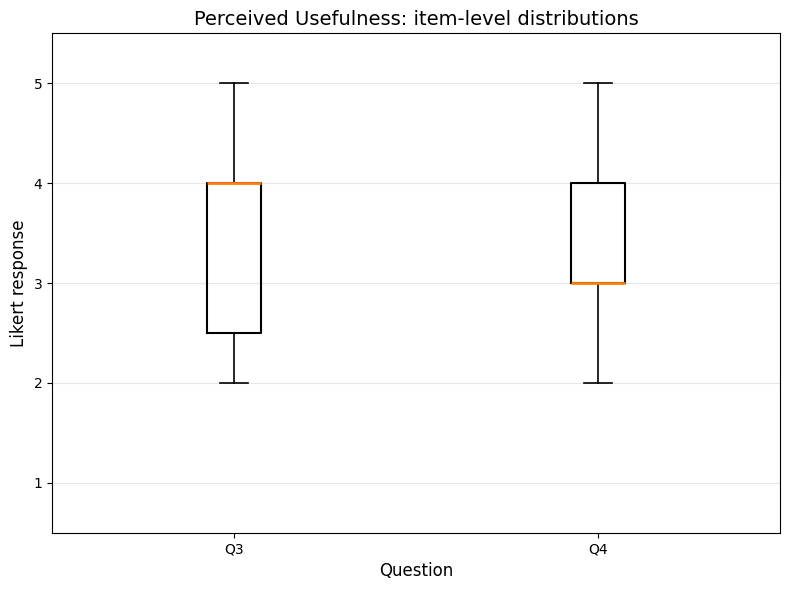

Saved: svg_plots/boxplot_clarity.svg


/var/folders/pn/c6dgbs01201d5v3_1pcfym1c0000gn/T/ipykernel_35531/4244229010.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


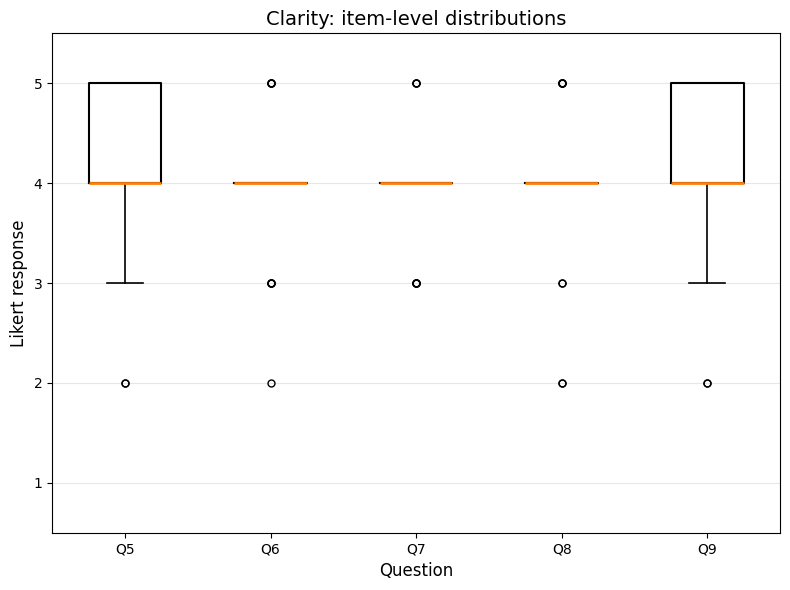

/var/folders/pn/c6dgbs01201d5v3_1pcfym1c0000gn/T/ipykernel_35531/4244229010.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: svg_plots/boxplot_social_expressiveness__appropriateness.svg


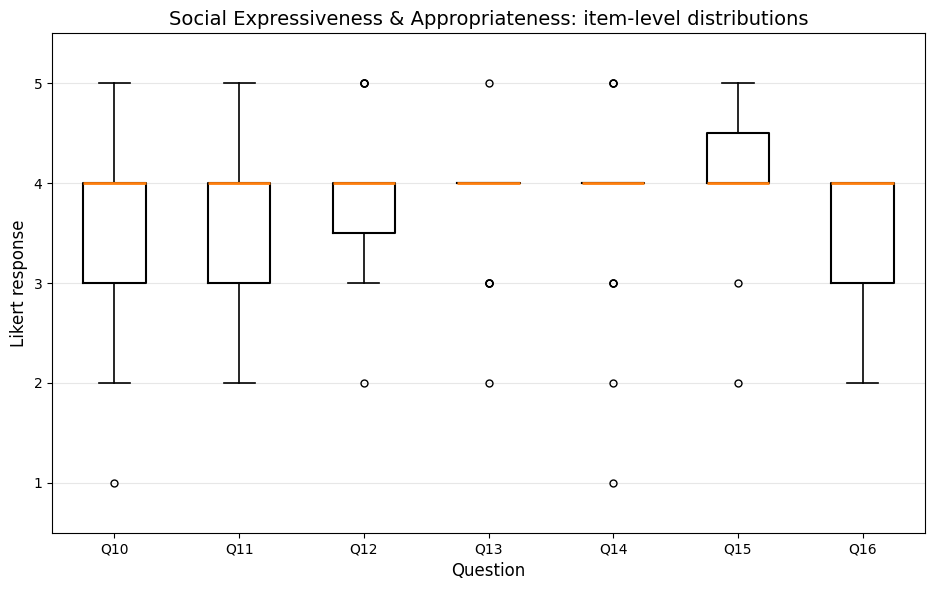

/var/folders/pn/c6dgbs01201d5v3_1pcfym1c0000gn/T/ipykernel_35531/4244229010.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: svg_plots/boxplot_trust_safety__comfort.svg


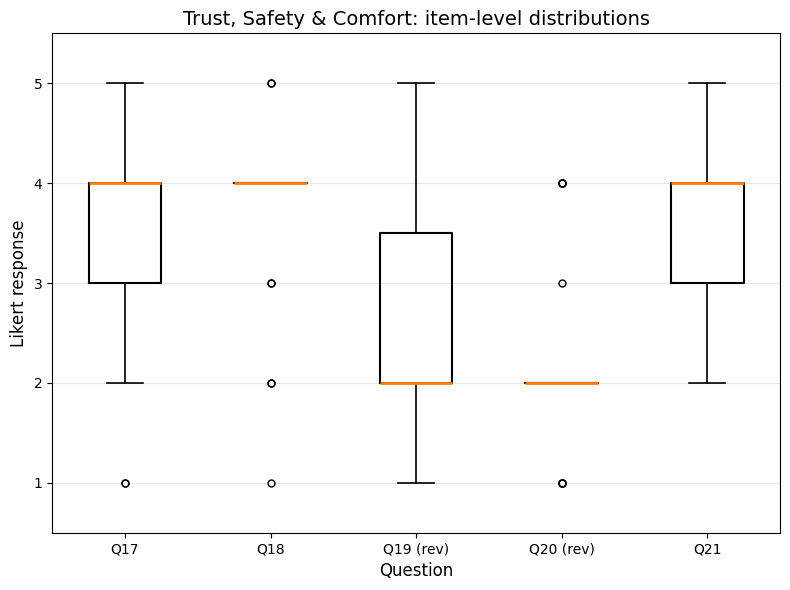

Saved: svg_plots/boxplot_all_constructs.svg


/var/folders/pn/c6dgbs01201d5v3_1pcfym1c0000gn/T/ipykernel_35531/4244229010.py:242: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


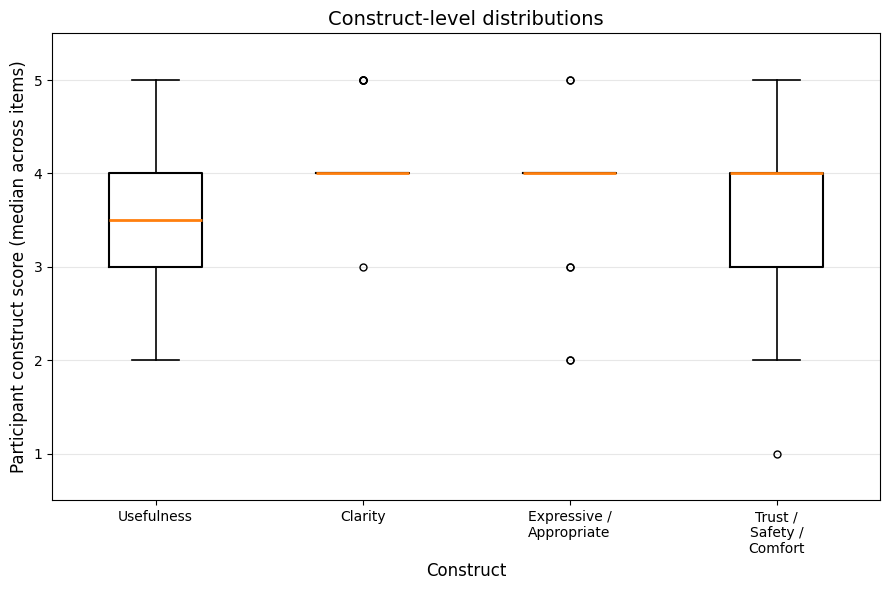

In [10]:
import os
import textwrap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================================================
# CONFIG: edit these settings to customize all plots
# =========================================================
PLOT_CONFIG = {
    # Output
    "output_dir": "svg_plots",
    "save_svg": True,
    "show_plots": True,
    "transparent_background": True,

    # Figure sizing
    "per_item_base_width": 1.35,     # width multiplier per question in construct plots
    "construct_plot_min_width": 8,
    "construct_plot_height": 6,
    "overall_plot_width": 9,
    "overall_plot_height": 6,

    # Typography
    "title_fontsize": 14,
    "label_fontsize": 12,
    "tick_fontsize": 10,

    # Axes / scale
    "ymin": 0.5,
    "ymax": 5.5,
    "yticks": [1, 2, 3, 4, 5],
    "xlabel_rotation": 0,
    "overall_xlabel_rotation": 0,

    # Boxplot styling
    "box_linewidth": 1.5,
    "median_linewidth": 2.0,
    "whisker_linewidth": 1.2,
    "cap_linewidth": 1.2,
    "flier_markersize": 5,

    # Grid
    "show_grid": True,
    "grid_axis": "y",
    "grid_alpha": 0.3,

    # Titles
    "per_construct_title_template": "{construct}: item-level distributions",
    "overall_title": "Construct-level distributions",

    # Labels
    "x_label_per_construct": "Question",
    "y_label_per_construct": "Likert response",
    "x_label_overall": "Construct",
    "y_label_overall": "Participant construct score (median across items)",

    # Wrapping
    "wrap_long_labels": False,
    "wrap_width": 12,
}

# =========================================================
# DATA DEFINITIONS
# Assumes your earlier stats cell already created `data`
# and reverse-coded Q19_R / Q20_R
# =========================================================
constructs_plot = {
    "Perceived Usefulness": ["Q3", "Q4"],
    "Clarity": ["Q5", "Q6", "Q7", "Q8", "Q9"],
    "Social Expressiveness & Appropriateness": ["Q10", "Q11", "Q12", "Q13", "Q14", "Q15", "Q16"],
    "Trust, Safety & Comfort": ["Q17", "Q18", "Q19_R", "Q20_R", "Q21"],
}

pretty_item_labels = {
    "Q3": "Q3",
    "Q4": "Q4",
    "Q5": "Q5",
    "Q6": "Q6",
    "Q7": "Q7",
    "Q8": "Q8",
    "Q9": "Q9",
    "Q10": "Q10",
    "Q11": "Q11",
    "Q12": "Q12",
    "Q13": "Q13",
    "Q14": "Q14",
    "Q15": "Q15",
    "Q16": "Q16",
    "Q17": "Q17",
    "Q18": "Q18",
    "Q19_R": "Q19 (rev)",
    "Q20_R": "Q20 (rev)",
    "Q21": "Q21",
}

construct_score_cols = {
    "Perceived Usefulness": "Perceived Usefulness_score",
    "Clarity": "Clarity_score",
    "Social Expressiveness & Appropriateness": "Social Expressiveness & Appropriateness_score",
    "Trust, Safety & Comfort": "Trust, Safety & Comfort_score",
}

overall_display_labels = {
    "Perceived Usefulness": "Usefulness",
    "Clarity": "Clarity",
    "Social Expressiveness & Appropriateness": "Expressive / Appropriate",
    "Trust, Safety & Comfort": "Trust / Safety / Comfort",
}

# Ensure reverse-coded columns exist
for col in ["Q19", "Q20"]:
    if col in data.columns and f"{col}_R" not in data.columns:
        data[f"{col}_R"] = data[col].apply(lambda x: 6 - x if pd.notna(x) else np.nan)

# Ensure output directory exists
os.makedirs(PLOT_CONFIG["output_dir"], exist_ok=True)

# =========================================================
# HELPERS
# =========================================================
def maybe_wrap(label, width=12, enabled=False):
    if not enabled:
        return label
    return "\n".join(textwrap.wrap(str(label), width=width))

def sanitize_filename(name):
    keep = []
    for ch in str(name):
        if ch.isalnum() or ch in ("_", "-", " "):
            keep.append(ch)
    return "".join(keep).strip().replace(" ", "_").lower()

def save_figure(fig, filename_base):
    if PLOT_CONFIG["save_svg"]:
        out_path = os.path.join(PLOT_CONFIG["output_dir"], f"{filename_base}.svg")
        fig.savefig(
            out_path,
            format="svg",
            bbox_inches="tight",
            transparent=PLOT_CONFIG["transparent_background"],
        )
        print(f"Saved: {out_path}")

def make_boxplot(ax, plot_data, labels):
    bp = ax.boxplot(
        plot_data,
        labels=labels,
        patch_artist=False,
        boxprops={"linewidth": PLOT_CONFIG["box_linewidth"]},
        medianprops={"linewidth": PLOT_CONFIG["median_linewidth"]},
        whiskerprops={"linewidth": PLOT_CONFIG["whisker_linewidth"]},
        capprops={"linewidth": PLOT_CONFIG["cap_linewidth"]},
        flierprops={"markersize": PLOT_CONFIG["flier_markersize"]},
    )

    ax.set_ylim(PLOT_CONFIG["ymin"], PLOT_CONFIG["ymax"])
    ax.set_yticks(PLOT_CONFIG["yticks"])

    if PLOT_CONFIG["show_grid"]:
        ax.grid(axis=PLOT_CONFIG["grid_axis"], alpha=PLOT_CONFIG["grid_alpha"])

    ax.tick_params(axis="x", labelsize=PLOT_CONFIG["tick_fontsize"])
    ax.tick_params(axis="y", labelsize=PLOT_CONFIG["tick_fontsize"])

    for label in ax.get_xticklabels():
        label.set_rotation(PLOT_CONFIG["xlabel_rotation"])

    return bp

# =========================================================
# 1) SAVE ONE SVG PER CONSTRUCT
# =========================================================
for construct_name, items in constructs_plot.items():
    plot_data = []
    labels = []

    for item in items:
        vals = pd.to_numeric(data[item], errors="coerce").dropna().values
        if len(vals) > 0:
            plot_data.append(vals)
            labels.append(
                maybe_wrap(
                    pretty_item_labels.get(item, item),
                    width=PLOT_CONFIG["wrap_width"],
                    enabled=PLOT_CONFIG["wrap_long_labels"],
                )
            )

    if len(plot_data) == 0:
        print(f"Skipping {construct_name}: no data")
        continue

    n_items = len(plot_data)
    fig_width = max(
        PLOT_CONFIG["construct_plot_min_width"],
        n_items * PLOT_CONFIG["per_item_base_width"]
    )

    fig, ax = plt.subplots(figsize=(fig_width, PLOT_CONFIG["construct_plot_height"]))
    make_boxplot(ax, plot_data, labels)

    ax.set_title(
        PLOT_CONFIG["per_construct_title_template"].format(construct=construct_name),
        fontsize=PLOT_CONFIG["title_fontsize"]
    )
    ax.set_xlabel(PLOT_CONFIG["x_label_per_construct"], fontsize=PLOT_CONFIG["label_fontsize"])
    ax.set_ylabel(PLOT_CONFIG["y_label_per_construct"], fontsize=PLOT_CONFIG["label_fontsize"])

    fig.tight_layout()

    save_figure(fig, f"boxplot_{sanitize_filename(construct_name)}")

    if PLOT_CONFIG["show_plots"]:
        plt.show()
    else:
        plt.close(fig)

# =========================================================
# 2) SAVE ONE OVERALL SVG WITH ONE BOX PER CONSTRUCT
# =========================================================
overall_plot_data = []
overall_labels = []

for construct_name, score_col in construct_score_cols.items():
    if score_col in data.columns:
        vals = pd.to_numeric(data[score_col], errors="coerce").dropna().values
        if len(vals) > 0:
            overall_plot_data.append(vals)
            overall_labels.append(
                maybe_wrap(
                    overall_display_labels.get(construct_name, construct_name),
                    width=PLOT_CONFIG["wrap_width"],
                    enabled=True,   # usually nicer for the overall plot
                )
            )

fig, ax = plt.subplots(
    figsize=(PLOT_CONFIG["overall_plot_width"], PLOT_CONFIG["overall_plot_height"])
)

bp = ax.boxplot(
    overall_plot_data,
    labels=overall_labels,
    patch_artist=False,
    boxprops={"linewidth": PLOT_CONFIG["box_linewidth"]},
    medianprops={"linewidth": PLOT_CONFIG["median_linewidth"]},
    whiskerprops={"linewidth": PLOT_CONFIG["whisker_linewidth"]},
    capprops={"linewidth": PLOT_CONFIG["cap_linewidth"]},
    flierprops={"markersize": PLOT_CONFIG["flier_markersize"]},
)

ax.set_title(PLOT_CONFIG["overall_title"], fontsize=PLOT_CONFIG["title_fontsize"])
ax.set_xlabel(PLOT_CONFIG["x_label_overall"], fontsize=PLOT_CONFIG["label_fontsize"])
ax.set_ylabel(PLOT_CONFIG["y_label_overall"], fontsize=PLOT_CONFIG["label_fontsize"])
ax.set_ylim(PLOT_CONFIG["ymin"], PLOT_CONFIG["ymax"])
ax.set_yticks(PLOT_CONFIG["yticks"])

if PLOT_CONFIG["show_grid"]:
    ax.grid(axis=PLOT_CONFIG["grid_axis"], alpha=PLOT_CONFIG["grid_alpha"])

ax.tick_params(axis="x", labelsize=PLOT_CONFIG["tick_fontsize"])
ax.tick_params(axis="y", labelsize=PLOT_CONFIG["tick_fontsize"])

for label in ax.get_xticklabels():
    label.set_rotation(PLOT_CONFIG["overall_xlabel_rotation"])

fig.tight_layout()

save_figure(fig, "boxplot_all_constructs")

if PLOT_CONFIG["show_plots"]:
    plt.show()
else:
    plt.close(fig)